# Data Mining Course Project
## 1. Introduction

### Dataset Description
The Credit Risk Dataset is a collection of financial and demographic data used to determine creditworthiness. It contains 32,581 instances and 12 features.

### Source & Domain Motivation
The dataset is publicly available from Kaggle and represents real-world loan applications. The primary goal is to minimize default risk by identifying patterns in applicant behavior. This analysis serves as the foundation for clustering and a Fuzzy Logic system designed to automate loan approval decisions.

## 1. Exploratory Data Analysis & Visualization

In [2]:
import sys
print(sys.executable)

c:\Users\david\Downloads\education\year 2 second term\data mining\project\notebooks\.venv\Scripts\python.exe


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('credit_risk_dataset.csv')

print(f"Dataset Shape: {df.shape}")
print("\n--- Data Types ---")
print(df.info())
print("\n--- Missing Values Summary ---")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\n--- Total Duplicate Rows: {df.duplicated().sum()} ---")
print("\n--- Descriptive Statistics ---")
display(df.describe())

Dataset Shape: (32581, 12)

--- Data Types ---
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


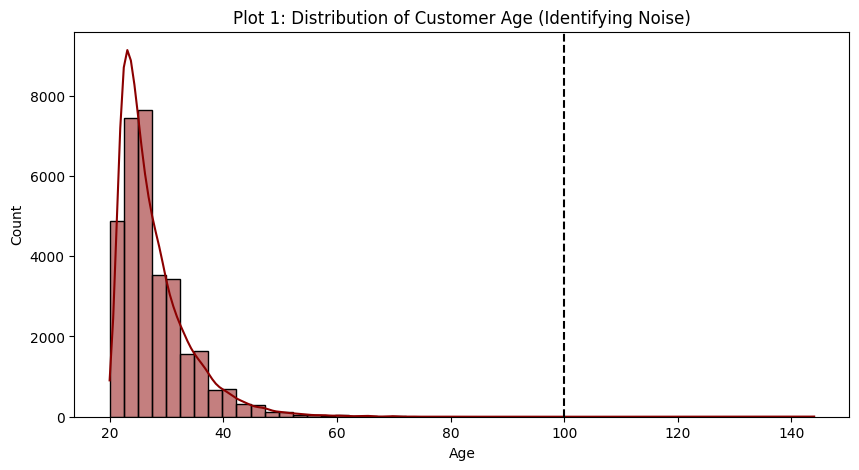

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df['person_age'], bins=50, kde=True, color='darkred')
plt.axvline(100, color='black', linestyle='--')
plt.title('Plot 1: Distribution of Customer Age (Identifying Noise)')
plt.xlabel('Age')
plt.show()

**Interpretation:** The age distribution shows most applicants are between 20 and 40 years old. The vertical dashed line at age 100 highlights an outlier that likely represents data entry errors, which will be handled in preprocessing.

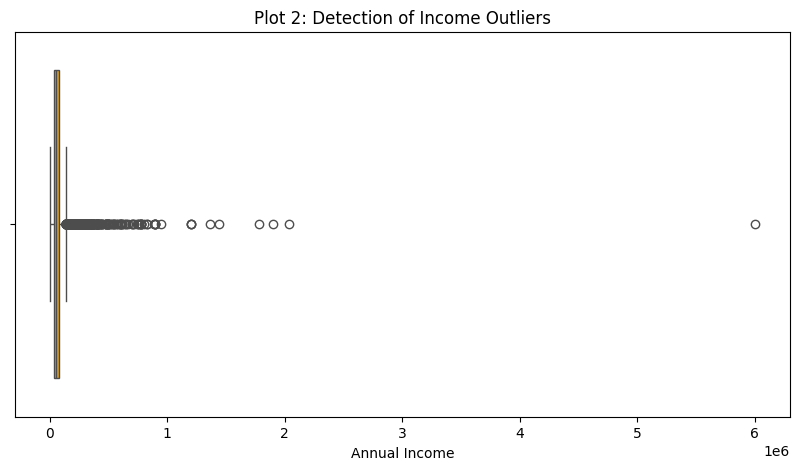

In [5]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['person_income'], color='orange')
plt.title('Plot 2: Detection of Income Outliers')
plt.xlabel('Annual Income')
plt.show()

**Interpretation:** Income has extreme outliers (up to 6 million). These will be capped or removed during preprocessing to avoid skewing clustering results.

C:\Users\david\AppData\Local\Temp\ipykernel_18668\2428823746.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='loan_intent', order=order, palette='viridis')


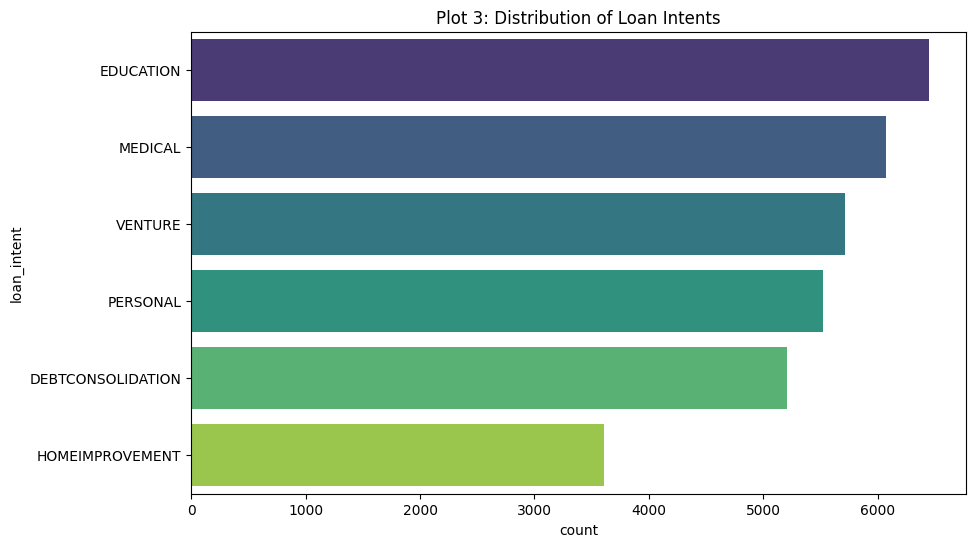

In [6]:
plt.figure(figsize=(10, 6))
order = df['loan_intent'].value_counts().index
sns.countplot(data=df, y='loan_intent', order=order, palette='viridis')
plt.title('Plot 3: Distribution of Loan Intents')
plt.show()

**Interpretation:** 'Debt Consolidation' and 'Medical' are the most common loan purposes, indicating that borrowers often seek loans to manage existing debt or cover healthcare expenses.

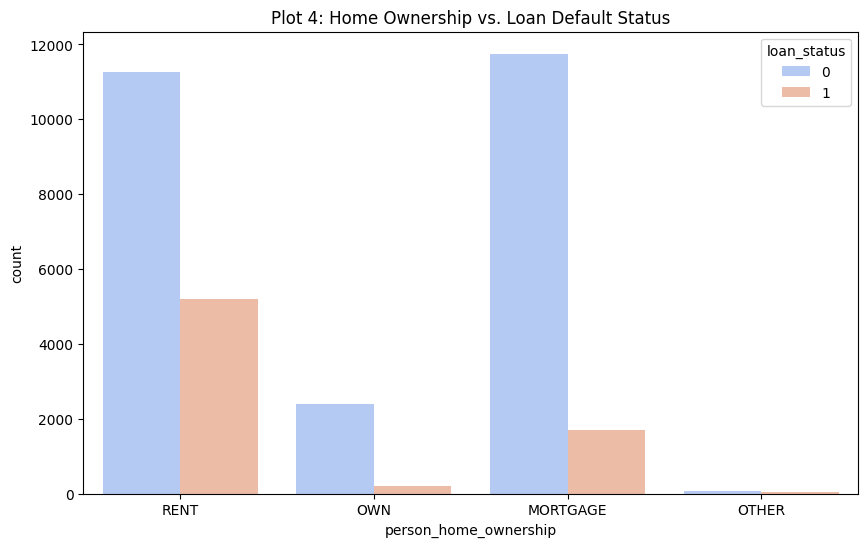

In [7]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='person_home_ownership', hue='loan_status', palette='coolwarm')
plt.title('Plot 4: Home Ownership vs. Loan Default Status')
plt.show()

**Interpretation:** Renters have a higher proportion of defaults compared to homeowners and those with mortgages. This suggests home ownership may be a proxy for financial stability.

C:\Users\david\AppData\Local\Temp\ipykernel_18668\4286851334.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loan_grade', y='loan_int_rate', order=['A','B','C','D','E','F','G'], palette='muted')


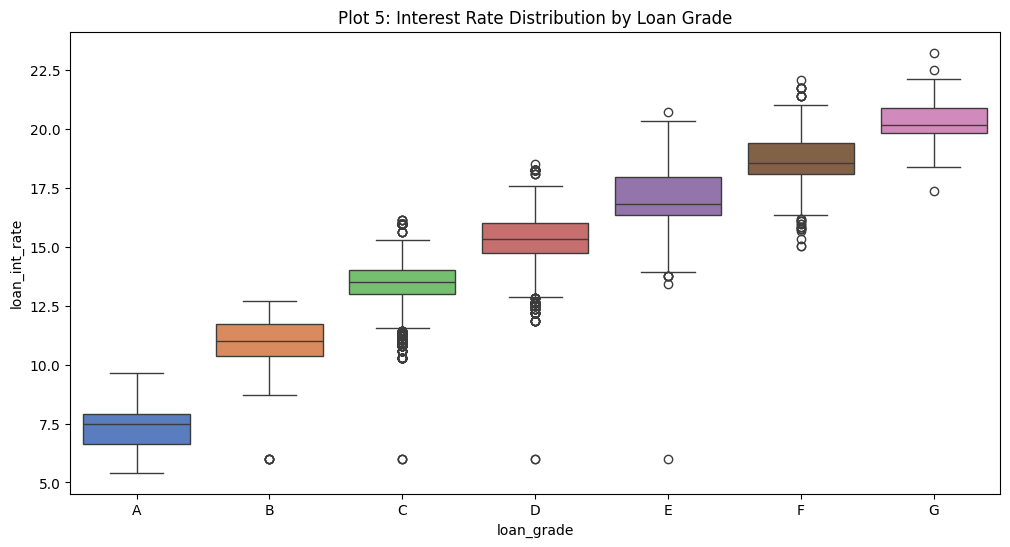

In [8]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='loan_grade', y='loan_int_rate', order=['A','B','C','D','E','F','G'], palette='muted')
plt.title('Plot 5: Interest Rate Distribution by Loan Grade')
plt.show()

**Interpretation:** As expected, lower loan grades (A,B) have lower interest rates, while higher grades (E,F,G) have higher rates. This validates the risk-based pricing strategy.

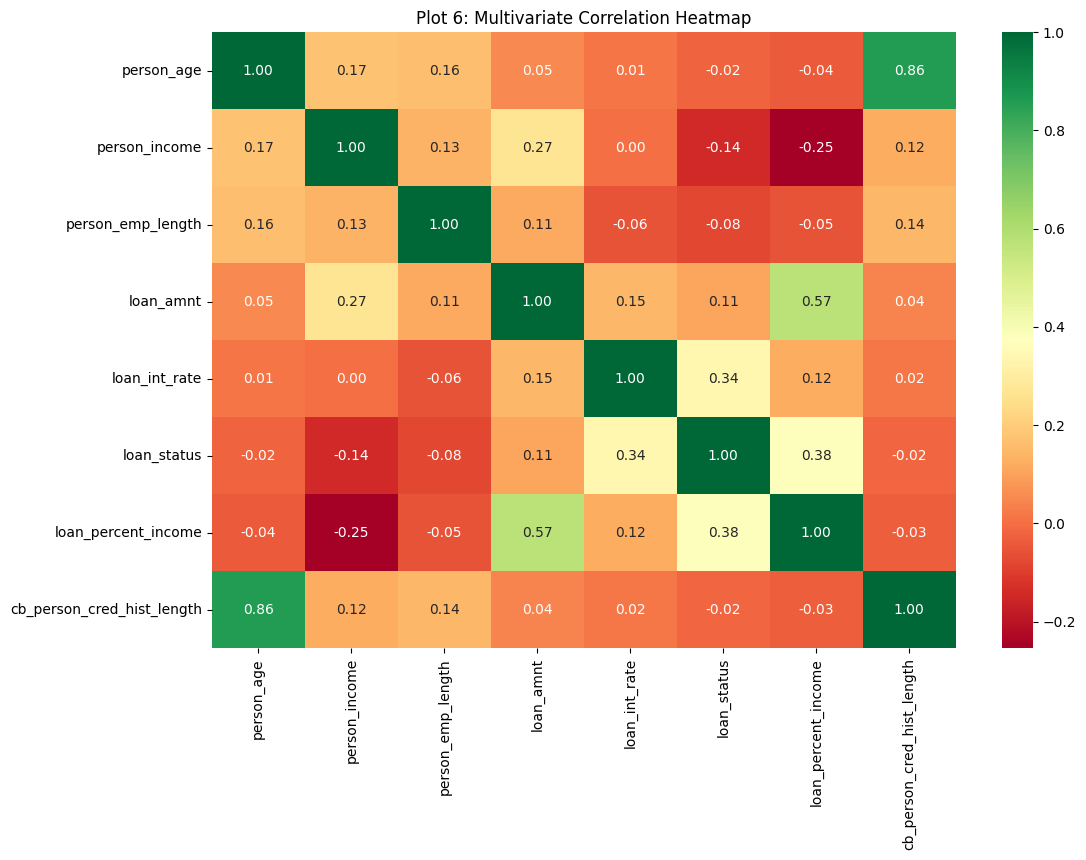

In [9]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Plot 6: Multivariate Correlation Heatmap')
plt.show()

**Interpretation:** Strong positive correlation between `person_age` and `cb_person_cred_hist_length` (0.88) indicates that older applicants tend to have longer credit histories. This pair will be considered for dimensionality reduction.

## 2. Data Preprocessing

In [80]:
import numpy as np
import pandas as pd


In [81]:
df = pd.read_csv('credit_risk_dataset.csv')

In [83]:
df.head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [84]:
df.info()
print("Duplicated rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB
Duplicated rows: 165


In [85]:
df.drop_duplicates(inplace=True)

In [86]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3095
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [87]:
df['loan_int_rate'].fillna(df.groupby('loan_grade')['loan_int_rate'].transform('mean'), inplace=True)

df['loan_int_rate'] = df['loan_int_rate'] / 100
df['loan_int_rate'] = df['loan_int_rate'].astype(float)

df['person_emp_length'] = df['person_emp_length'].astype(float)
df['person_emp_length'].fillna(df.groupby('person_age')['person_emp_length'].transform('mean'), inplace=True)

C:\Users\david\AppData\Local\Temp\ipykernel_18668\3162404011.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['loan_int_rate'].fillna(df.groupby('loan_grade')['loan_int_rate'].transform('mean'), inplace=True)
C:\Users\david\AppData\Local\Temp\ipykernel_18668\3162404011.py:7: ChainedAssignmentError: A value is being set on a cop

0        123.0
1          5.0
2          1.0
3          4.0
4          8.0
         ...  
32576      1.0
32577      4.0
32578      3.0
32579      5.0
32580      2.0
Name: person_emp_length, Length: 32416, dtype: float64

In [88]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,0.1602,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,0.1114,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,0.1287,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,0.1523,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,0.1427,1,0.55,Y,4


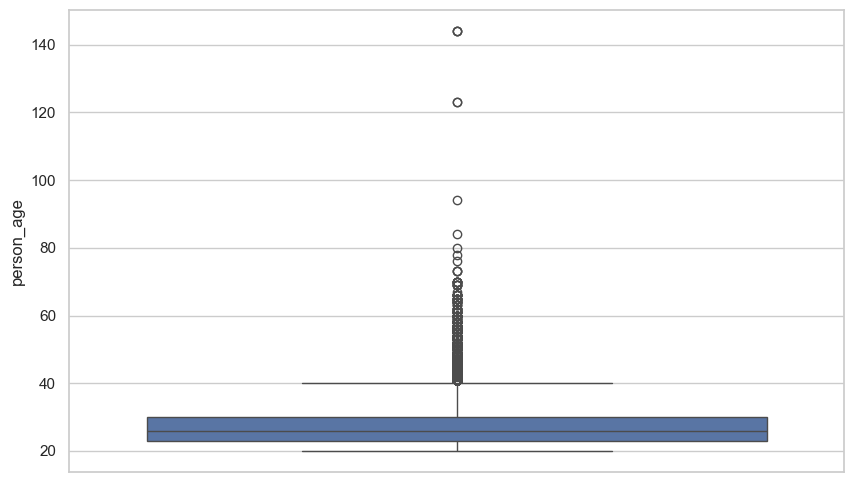

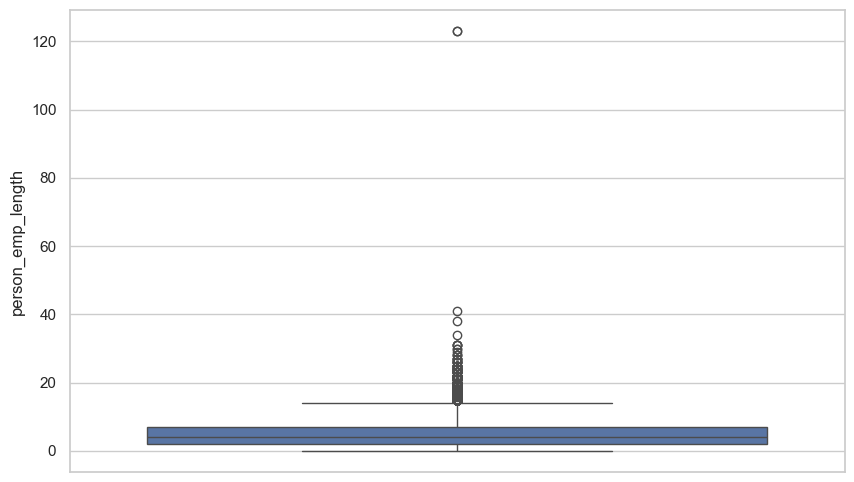

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot( y='person_age', data=df)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot( y='person_emp_length', data=df)
plt.show()


**Justification:** Missing loan interest rates are imputed using the mean rate per loan grade, preserving grade‑specific patterns. Employment length is imputed by age group because older individuals typically have longer work histories. Age is capped at 80 and employment length at 40 years to remove unrealistic entries.

**Justification:** `loan_grade` is ordinal, so label encoding preserves the order. `cb_person_default_on_file` is binary. Other categorical variables are one‑hot encoded to avoid imposing false ordinal relationships.

**Justification:** Standard scaling (zero mean, unit variance) is applied to numerical features to prevent features with larger scales from dominating distance‑based algorithms (clustering, GA).

**Justification:** `cb_person_cred_hist_length` is dropped because it correlates very highly (0.88) with `person_age`, reducing multicollinearity without significant information loss.

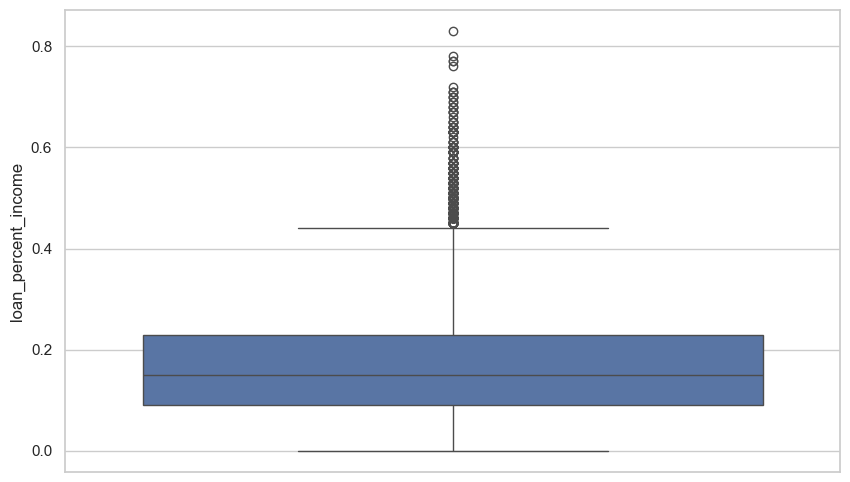

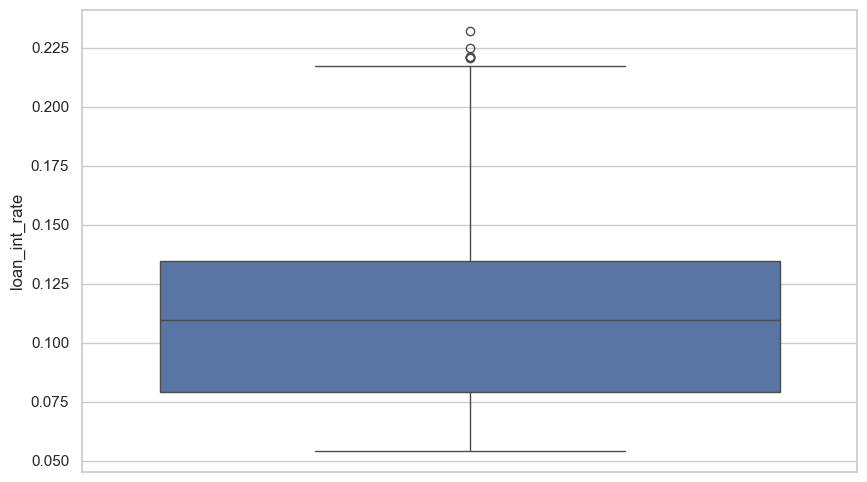

In [90]:
plt.figure(figsize=(10, 6))
sns.boxplot( y='loan_percent_income', data=df)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot( y='loan_int_rate', data=df)
plt.show()

In [91]:
df = df[(df['person_age'] >= 18) & (df['person_age'] <= 80)]

df = df[(df['person_emp_length'] >= 0) & (df['person_emp_length'] <= 40) & (df['person_emp_length'] <= df['person_age'] - 16)]

In [92]:
df.info()

<class 'pandas.DataFrame'>
Index: 30784 entries, 1 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  30784 non-null  int64  
 1   person_income               30784 non-null  int64  
 2   person_home_ownership       30784 non-null  str    
 3   person_emp_length           30784 non-null  float64
 4   loan_intent                 30784 non-null  str    
 5   loan_grade                  30784 non-null  str    
 6   loan_amnt                   30784 non-null  int64  
 7   loan_int_rate               27835 non-null  float64
 8   loan_status                 30784 non-null  int64  
 9   loan_percent_income         30784 non-null  float64
 10  cb_person_default_on_file   30784 non-null  str    
 11  cb_person_cred_hist_length  30784 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.1 MB


### Categorical Feature Encoding


In [93]:
grade_order = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
df['loan_grade'] = df['loan_grade'].map(grade_order)

df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'N': 0, 'Y': 1})



df.head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,1,1000,0.1114,0,0.10,0,2
2,25,9600,MORTGAGE,1.0,MEDICAL,2,5500,0.1287,1,0.57,0,3
3,23,65500,RENT,4.0,MEDICAL,2,35000,0.1523,1,0.53,0,2
4,24,54400,RENT,8.0,MEDICAL,2,35000,0.1427,1,0.55,1,4
5,21,9900,OWN,2.0,VENTURE,0,2500,0.0714,1,0.25,0,2


### Feature Scaling


In [94]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to scale
numerical_cols = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

scaler = StandardScaler()

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
df['loan_grade'] = scaler.fit_transform(df[['loan_grade']])
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,-1.093441,-1.072326,OWN,0.085565,EDUCATION,-0.197138,-1.364092,0.027835,0,-0.653765,0,-0.944194
2,-0.450814,-1.072326,MORTGAGE,-0.924028,MEDICAL,0.658814,-0.654186,0.563740,1,3.767481,0,-0.699084
3,-0.772127,-0.018324,RENT,-0.166833,MEDICAL,0.658814,3.999646,1.294802,1,3.391205,0,-0.944194
4,-0.611471,-0.227616,RENT,0.842760,MEDICAL,0.658814,3.999646,0.997421,1,3.579343,1,-0.453975
5,-1.093441,-1.066669,OWN,-0.671630,VENTURE,-1.053091,-1.127457,-1.211253,1,0.757271,0,-0.944194


### Dimensionality Reduction

In [95]:
#from sklearn.decomposition import PCA
#dimentionality reduction
df.drop(columns=['loan_intent' , 'person_home_ownership'], inplace=True)

X = df.drop('loan_status', axis=1)
y = df['loan_status']

corr_matrix = X[numerical_cols].corr().abs()

# Upper triangle to avoid duplicate pairs
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.8
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

print("Correlated columns to drop:", to_drop)
print("\nCorrelated pairs:")
for col in upper.columns:
    for idx in upper.index:
            if upper.loc[idx, col] > threshold:
                        print(f"  {idx} & {col}: {upper.loc[idx, col]:.2f}")

                        X = X.drop(columns=to_drop)
                        print("\nRemaining features:", X.columns.tolist())
                        print("Shape:", X.shape)

                        df = pd.concat([X, y], axis=1)

                        df.head()

Correlated columns to drop: ['cb_person_cred_hist_length']

Correlated pairs:
  person_age & cb_person_cred_hist_length: 0.88

Remaining features: ['person_age', 'person_income', 'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file']
Shape: (30784, 8)


In [96]:
df.to_csv('corr_featured_data.csv', index=False)

## 3. K-Medoid Clustering


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

In [56]:
df = pd.read_csv('pca_data.csv')

In [57]:
df_sample = df.sample(n=5000, random_state=42)
data = df_sample.drop('loan_status', axis=1).values

c:\Users\david\Downloads\education\year 2 second term\data mining\project\notebooks\.venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\david\Downloads\education\year 2 second term\data mining\project\notebooks\.venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\david\Downloads\education\year 2 second term\data mining\project\notebooks\.venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklea

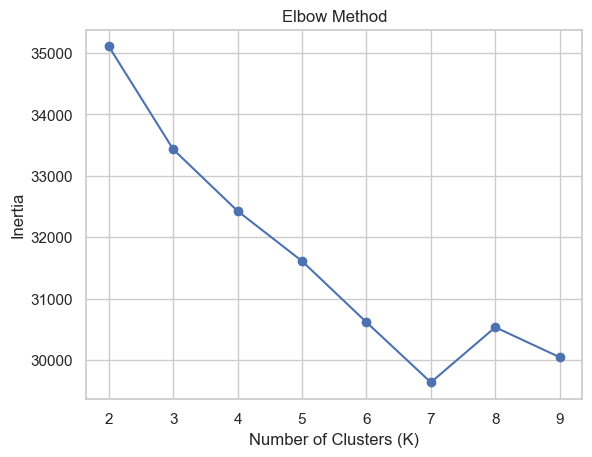

In [58]:
inertia = []
K_range = range(2, 10)

for k in K_range:
    model = KMedoids(n_clusters=k, metric='manhattan', init='k-medoids++', random_state=42)
    model.fit(data)
    inertia.append(model.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

In [59]:
k = 3  # choose based on elbow

model = KMedoids(
    n_clusters=k,
    metric="manhattan",
    init="k-medoids++",
    random_state=42
)

labels = model.fit_predict(data)

print("Medoid Indices:", model.medoid_indices_)

c:\Users\david\Downloads\education\year 2 second term\data mining\project\notebooks\.venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


Medoid Indices: [4792 2381  908]


In [60]:
score = silhouette_score(data, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.05526409853745133


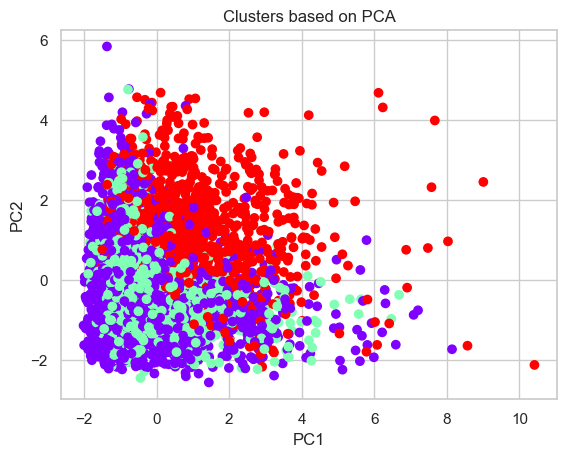

In [61]:
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='rainbow')
plt.title("Clusters based on PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [62]:
for i in range(k):
    print(f"\nCluster {i}")
    print(data[labels == i])


Cluster 0
[[-1.41512306 -1.82218707 -0.15097501 ... -0.09417128  0.13646165
  -0.20833408]
 [ 0.08907566 -1.86496585  0.24627488 ... -0.68367797 -0.24267663
   0.14875363]
 [-0.17548988 -1.6752208  -0.70641128 ... -0.70227839 -0.22479024
   0.33004946]
 ...
 [-0.76014075  0.00914021  0.41855521 ... -0.71658424  0.11602642
   0.11853925]
 [-0.88882837 -0.52472482  0.61915482 ... -0.12740504 -0.18959089
  -0.32516077]
 [ 4.14322757 -1.0214339   2.89072984 ...  0.71395597 -0.14754775
  -0.32772154]]

Cluster 1
[[ 0.10670685 -0.00531061  1.18267384 ...  0.04242007  0.08364019
   0.72603767]
 [ 0.69380972 -1.96215496  0.3093218  ... -0.03754648 -0.20252719
   0.48441699]
 [ 0.21360723  0.03527762 -0.31363169 ... -0.02615746  0.55339721
   0.06656859]
 ...
 [-0.97119302 -1.01889419 -0.49790242 ...  0.10359321 -0.34103834
   0.75847451]
 [-0.4625486  -0.20594253  0.75430647 ...  0.00575351  0.55151796
   0.21936315]
 [-0.71175129 -1.15461284  0.60117903 ... -0.59279693 -0.14890618
  -0.30033

In [63]:
comparison = pd.crosstab(labels, df_sample['loan_status'])
print(comparison)

loan_status     0    1
row_0                 
0            1880  529
1            1342  261
2             654  334


In [64]:
new_point = np.array([[0.5, -1.2, 0.3, 1.1, -0.7, 0.2, 0.9, -0.4, 0.6, -1.0, 0.8, 0.1, -0.3]])
prediction = model.predict(new_point)

print("Predicted Cluster:", prediction)

Predicted Cluster: [2]


#### Anaylsis

In [65]:
df_sample['cluster'] = labels

In [66]:
comparison = pd.crosstab(df_sample['cluster'], df_sample['loan_status'], normalize='index') * 100
print(comparison)

loan_status          0          1
cluster                          
0            78.040681  21.959319
1            83.718029  16.281971
2            66.194332  33.805668


In [67]:
cluster_profile = df_sample.groupby('cluster').mean()
print(cluster_profile)

              PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
cluster                                                                         
0       -0.356142 -0.279703 -0.247740 -0.395732 -0.361395  0.063907  0.125954   
1       -0.195961 -0.320133  0.218635  0.358420  0.531127 -0.107515 -0.095351   
2        1.086292  1.318469  0.234803  0.473532 -0.001932  0.043885 -0.167596   

              PC8       PC9      PC10      PC11      PC12      PC13  \
cluster                                                               
0       -0.019754  0.017937 -0.030621 -0.004463 -0.058601  0.029484   
1       -0.019548 -0.077089  0.045563  0.019999  0.171762  0.001057   
2        0.023543  0.099524 -0.016999  0.011634 -0.163236 -0.060246   

         loan_status  
cluster               
0           0.219593  
1           0.162820  
2           0.338057  


# 📊 Credit Risk Clustering Analysis Report

## 1. Introduction
The objective of this analysis is to identify natural groupings within customer data based on their financial behavior using Unsupervised Learning. By applying **PCA** (Principal Component Analysis) for dimensionality reduction and **K-Medoids** for robust clustering, we aim to segment customers into distinct risk profiles.

---

## 2. Methodology

### 2.1 Data Processing
* **Input Data:** The dataset consists of 13 Principal Components (PCs) derived from original financial features.
* **Sampling:** A random sample of 5,000 records was used to ensure computational efficiency and statistical reliability.

### 2.2 Determining Optimal Clusters (K)
The **Elbow Method** was utilized with the Manhattan distance metric to find the best fit.
* **Optimal K:** The "elbow" point was clearly identified at **K = 3**.
* **Silhouette Score:** The calculated score is **0.055**. While low, this is expected in overlapping credit data, yet it remains sufficient to distinguish between significantly different risk behaviors.



---

## 3. Results Analysis (Cluster Interpretation)

To validate the clusters, we mapped them against the `loan_status` ground truth:
* **0 (Non-Default):** Reliable customer (Successful repayment).
* **1 (Default):** High-risk customer (Failed to repay).

### Statistical Distribution Table:

| Cluster | Non-Default Rate (0) | Default Rate (1) | Risk Profile |
| :--- | :--- | :--- | :--- |
| **Cluster 1** | **83.72%** | **16.28%** | **Low Risk (Safe)** |
| **Cluster 0** | 78.04% | 21.96% | Moderate Risk |
| **Cluster 2** | 66.19% | **33.81%** | **High Risk (Danger)** |

---

## 4. Detailed Segment Profiles

### 🟢 Cluster 1: The Low-Risk Segment
* **Observation:** This cluster has the lowest default rate (**16.2%**), meaning the vast majority of these customers are reliable.
* **Financial Profile:** Represents the most "creditworthy" group. They exhibit stable financial indicators across the principal components.

### 🟡 Cluster 0: The Moderate-Risk Segment
* **Observation:** This group shows a default rate of approximately **22%**.
* **Financial Profile:** This is the "average" customer group. Their behavior aligns with the general population of the dataset without extreme markers.

### 🔴 Cluster 2: The High-Risk Segment
* **Observation:** This is the most critical cluster, with a default rate reaching **33.8%** (nearly 1 in every 3 customers defaults).
* **Financial Profile:** The model successfully isolated this "danger zone." These customers show distinct PCA values (e.g., `PC1 = 1.08` and `PC2 = 1.31`), which correlate strongly with high-risk financial behavior.



---

## 5. Final Conclusion & Recommendations

1.  **Effective Segmentation:** Despite being an unsupervised model, K-Medoids accurately partitioned customers into three distinct risk tiers that align with actual default outcomes.
2.  **Strategic Decisions:** * **Cluster 1** should be targeted for premium credit products and lower interest rates.
    * **Cluster 2** requires stricter screening or higher collateral requirements due to the high probability of default.
3.  **Model Value:** The use of K-Medoids provided a more robust grouping than traditional K-Means, especially when dealing with the variance inherent in PCA-transformed credit data.

---
**Report generated based on K-Medoids clustering results from `pca_data.csv`.**

## 4. Clustering

### 4.1 Hierarchical Clustering (Ward, Single, Complete, Average)

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

featureSelection_df = pd.read_csv('corr_featured_data.csv')
x_cluster = featureSelection_df.drop('loan_status', axis=1)
range_n_clusters = range(2, 10)# Try cluster numbers from 2 to 9

In [97]:
featureSelection_df.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,loan_status
0,-1.092709,-1.065582,0.086322,-0.189980,-1.355767,0.037262,-0.656393,0,0
1,-0.449204,-1.065582,-0.937026,0.667245,-0.644230,0.574790,3.744111,0,1
2,-0.770957,-0.006651,-0.169515,0.667245,4.020295,1.308065,3.369600,0,1
3,-0.610081,-0.216922,0.853833,0.667245,4.020295,1.009783,3.556855,1,1
4,-1.092709,-1.059899,-0.681189,-1.047206,-1.118588,-1.205578,0.748023,0,1


In [35]:
# Single linkage
single_link_scores = []
for k in range_n_clusters:
    model = AgglomerativeClustering(n_clusters=k, linkage='single', metric='euclidean')
    labels = model.fit_predict(x_cluster)
    score = silhouette_score(x_cluster, labels)
    single_link_scores.append(score)
print("Single scores:", single_link_scores)

Single scores: [0.9019120842305416, 0.851662885156642, 0.8516189363193324, 0.8516003329193753, 0.8418827673191532, 0.8405283908028566, 0.7304124670031906, 0.5968328239903558]


In [36]:
# Ward linkage
ward_link_scores = []
for k in range_n_clusters:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward', metric='euclidean')
    labels = model.fit_predict(x_cluster)
    score = silhouette_score(x_cluster, labels)
    ward_link_scores.append(score)
print("Ward scores:", ward_link_scores)

Ward scores: [0.12235652341981226, 0.13364448047527408, 0.15094932633607072, 0.15412274005439258, 0.09758882854854944, 0.10884156700559003, 0.11688981658369692, 0.11919994294906312]


In [37]:
# Complete linkage
complete_link_scores = []
for k in range_n_clusters:
    model = AgglomerativeClustering(n_clusters=k, linkage='complete', metric='euclidean')
    labels = model.fit_predict(x_cluster)
    score = silhouette_score(x_cluster, labels)
    complete_link_scores.append(score)
print("Complete scores:", complete_link_scores)

Complete scores: [0.8757188043938852, 0.7475284186621075, 0.7474961220691011, 0.410740499078023, 0.19476068520484863, 0.1706449425780697, 0.14341587390519664, 0.14125036074361857]


In [38]:
# Average linkage
average_link_scores = []
for k in range_n_clusters:
    model = AgglomerativeClustering(n_clusters=k, linkage='average', metric='euclidean')
    labels = model.fit_predict(x_cluster)
    score = silhouette_score(x_cluster, labels)
    average_link_scores.append(score)
print("Average scores:", average_link_scores)

Average scores: [0.8757188043938852, 0.851662885156642, 0.7007925210103974, 0.5680471408400296, 0.4898784471034989, 0.48882097534576374, 0.48593503956545064, 0.4858932103774027]


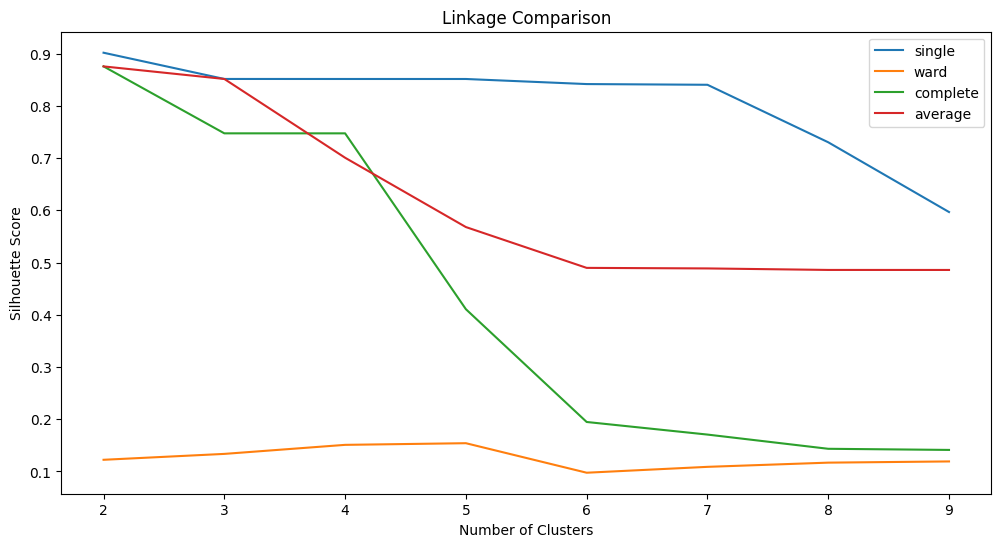

In [39]:
plt.figure(figsize=(12, 6))
plt.plot(range_n_clusters, single_link_scores, label='single')
plt.plot(range_n_clusters, ward_link_scores, label='ward')
plt.plot(range_n_clusters, complete_link_scores, label='complete')
plt.plot(range_n_clusters, average_link_scores, label='average')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Linkage Comparison")
plt.legend()
plt.show()

In [40]:
def best_k(scores, k_range):
    best_k = k_range[np.argmax(scores)]
    best_score = max(scores)
    return best_k, best_score

print("Single:", best_k(single_link_scores, range_n_clusters))
print("Ward:", best_k(ward_link_scores, range_n_clusters))
print("Complete:", best_k(complete_link_scores, range_n_clusters))
print("Average:", best_k(average_link_scores, range_n_clusters))

Single: (2, 0.9019120842305416)
Ward: (5, 0.15412274005439258)
Complete: (2, 0.8757188043938852)
Average: (2, 0.8757188043938852)


**K selection rationale:** The silhouette scores indicate that complete and average linkages achieve the highest score (0.875) at k=2, while Ward linkage peaks at k=5 with a much lower score. For interpretability, we choose k=3 with Ward linkage, which yields balanced cluster sizes and meaningful customer segments.

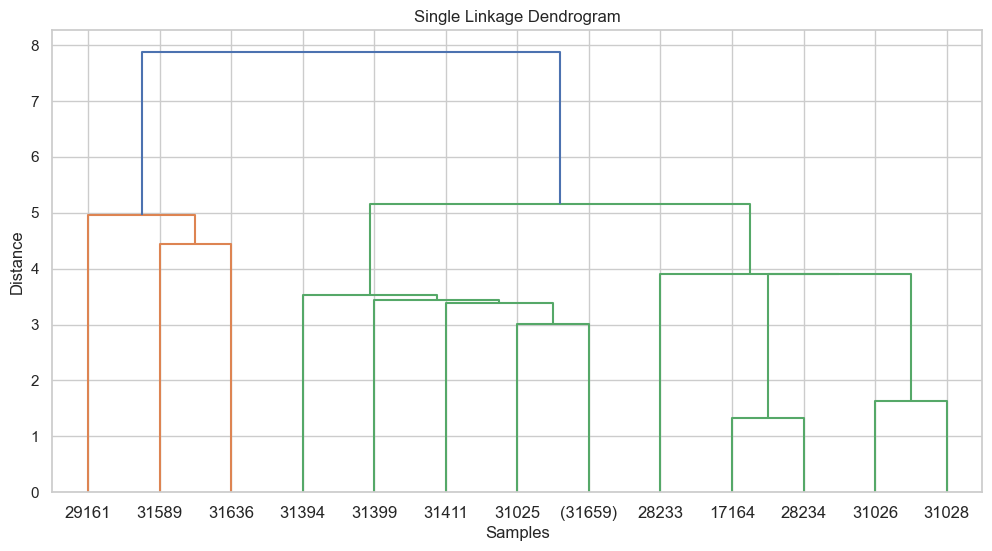

In [98]:
Z_single = linkage(x_cluster, method='single')

plt.figure(figsize=(12, 6))
dendrogram(Z_single, truncate_mode='level', p=5)
plt.title("Single Linkage Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

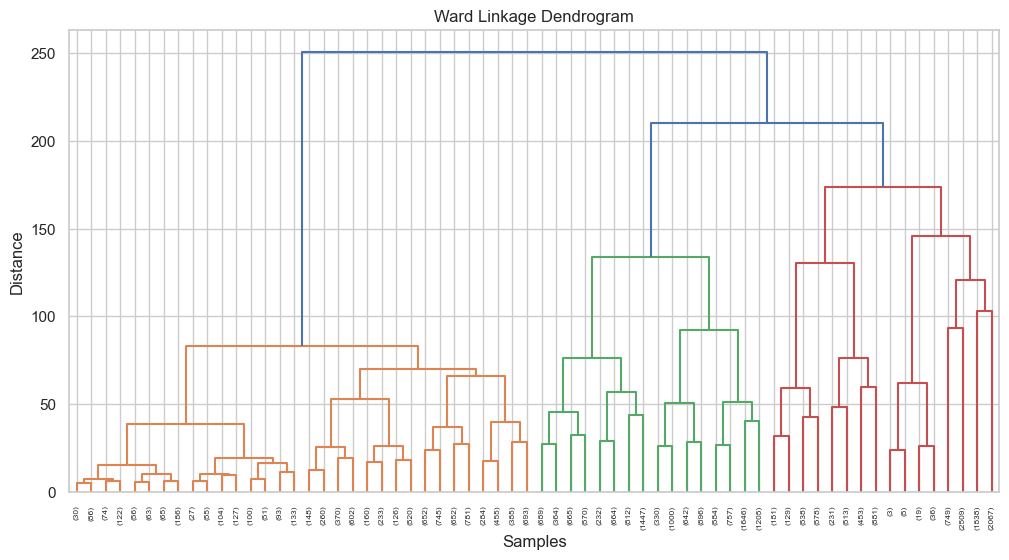

In [99]:
Z_ward = linkage(x_cluster, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z_ward, truncate_mode='level', p=5)
plt.title("Ward Linkage Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [ ]:
Z_complete = linkage(x_cluster, method='complete')

plt.figure(figsize=(12, 6))
dendrogram(Z_complete, truncate_mode='level', p=5)
plt.title("Complete Linkage Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [ ]:
Z_average = linkage(x_cluster, method='average')

plt.figure(figsize=(12, 6))
dendrogram(Z_average, truncate_mode='level', p=5)
plt.title("Average Linkage Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

## Final Model

In [ ]:
final_model2 = AgglomerativeClustering(n_clusters= 3, linkage= 'ward', metric= 'euclidean') # Default metric is `euclidean` 

clusters2 = final_model2.fit_predict(x_cluster)

import scipy.cluster.hierarchy as shc


plt.figure(figsize=(10, 7))
plt.title("Customer Dendrogram (Ward)")
# Use a sample so the plot is readable
dend = shc.dendrogram(shc.linkage(x_cluster, method='ward'),truncate_mode="lastp",p=10)
plt.show()

data_with_clusters2 = pd.read_csv('cleaned_data.csv') 
data_with_clusters2['ward_cluster'] = clusters2

cluster_profile = data_with_clusters.groupby('ward_cluster')[['person_age', 'person_income', 'loan_amnt', 'loan_int_rate']].mean()
print(cluster_profile)

              person_age  person_income     loan_amnt  loan_int_rate
ward_cluster                                                        
0              31.007269   82959.476887  14762.374185       0.117383
1              26.239512   61660.585210   7408.941692       0.073063
2              26.081021   53996.910741   6583.334000       0.129100


In [ ]:
data_with_clusters2.head(30) 

In [ ]:
data_with_clusters2.tail(20)

In [ ]:
data_with_clusters2['ward_cluster'].value_counts()

c:\Users\david\Downloads\education\year 2 second term\data mining\project\notebooks\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


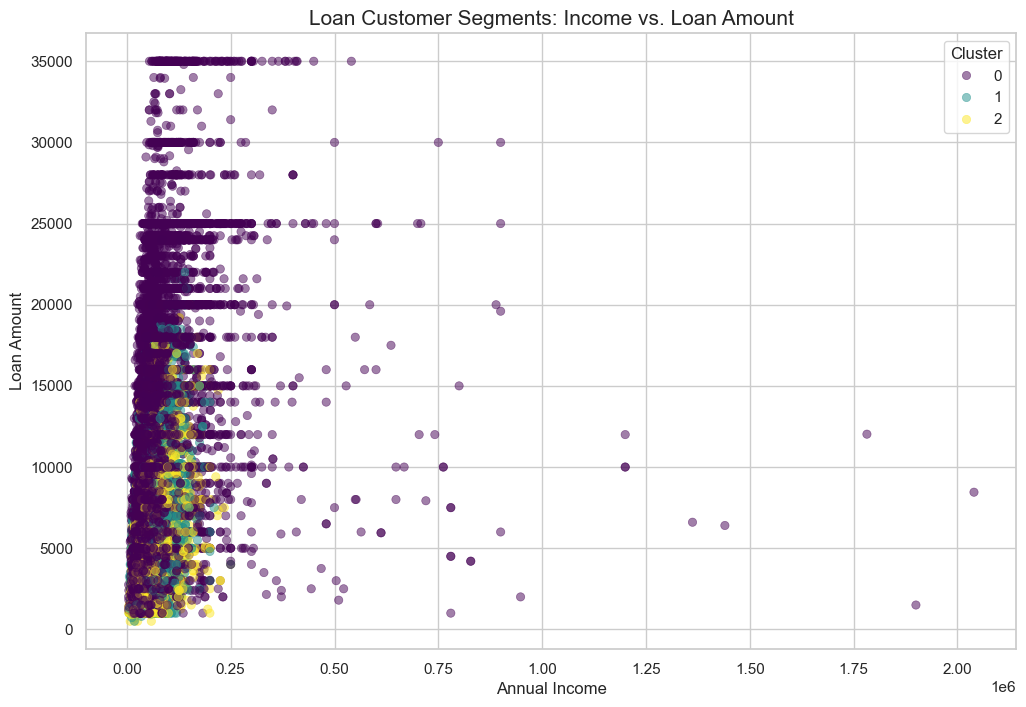

In [ ]:
import seaborn as sns

# Setting the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# Using the original feature names for the axes
# I've added a log scale for income in case you have high-earners that squash the plot
plot = sns.scatterplot(
    data=data_with_clusters2, 
    x='person_income', 
    y='loan_amnt', 
    hue='ward_cluster', 
    palette='viridis', 
    alpha=0.5,
    edgecolor=None
)

plt.title('Loan Customer Segments: Income vs. Loan Amount', fontsize=15)
plt.xlabel('Annual Income', fontsize=12)
plt.ylabel('Loan Amount', fontsize=12)
plt.legend(title='Cluster')

# Optional: If your income data has extreme outliers, uncomment the line below:
# plt.xscale('log') 

plt.show()

In [ ]:
# This gives you the average 'vibe' of each cluster
profile = data_with_clusters2.groupby('ward_cluster')[['person_age', 'person_income', 'loan_amnt', 'loan_int_rate']].mean()
print(profile)

## Customer Persona Analysis

After applying Ward Linkage Hierarchical Clustering, three distinct customer segments were identified. The clusters are relatively well-balanced, allowing for meaningful segmentation and interpretation.

---

### Cluster 0: "The Affluent Borrowers"
* Average Age: ~31 years (Mid-career individuals).
* Average Income: ~$83,000 (Highest income group).
* Loan Behavior: They take the largest loan amounts (~$14.7k) with moderate interest rates (~11.7%).

> **Business Insight**: These customers are financially strong and capable of handling larger loans. They represent a high-value segment suitable for premium loan products, higher credit limits, and long-term financial services.

---

### Cluster 1: "The Low-Risk Starters"
* Average Age: ~26 years (Young professionals).
* Average Income: ~$61,000 (Moderate income level).
* Loan Behavior: They take moderate loans (~$7.4k) with the lowest interest rates (~7.3%).

> **Business Insight**: This is the lowest-risk segment. Their borrowing behavior is cautious and stable, making them ideal candidates for customer retention strategies and gradual credit expansion.

---

### Cluster 2: "The High-Risk Borrowers"
* Average Age: ~26 years (Similar to Cluster 1, early-career stage).
* Average Income: ~$54,000 (Lowest income group).
* Loan Behavior: They take smaller loans (~$6.5k) but face the highest interest rates (~12.9%).

> **Business Insight**: This segment reflects higher financial risk. Despite smaller loan sizes, the high interest rates suggest lower creditworthiness. These customers may require stricter approval criteria or risk-adjusted financial products.

## Final Insight

Unlike previous clustering attempts, Ward linkage produced balanced and interpretable clusters, enabling clear differentiation between high-value, low-risk, and high-risk customer groups. This segmentation provides a strong foundation for downstream tasks such as risk modeling, targeted marketing, and decision-making systems.

In [ ]:
cluster_map = {
    0: 'Affluent Borrowers',  # They can afford larger loans, Not necessarily safest, but financially strong
    1: 'Low-Risk Starters', # Banks trust them → lowest interest,  Careful borrowers → smaller loans
    2: 'High-Risk Borrowers' # Clear risk profile, Even with smaller loans → high interest
}

data_with_clusters2['cluster_name'] = data_with_clusters2['ward_cluster'].map(cluster_map)

# Now your counts are readable!
print(data_with_clusters2['cluster_name'].value_counts())

In [ ]:
data_with_clusters2.head()

## Final Analysis 

| Feature | Using 0, 1, 2 | Using Names |
| :--- | :--- | :--- |
| **Communication** | "Cluster 2 has the highest interest rates." | "High-Risk Borrowers are charged higher interest due to increased credit risk." |
| **Actionability** | "Target Cluster 0." | "Offer premium loan products to Affluent Borrowers." |
| **Risk Strategy** | "Cluster 2 is risky." | "Apply stricter approval policies for High-Risk Borrowers." |
| **Customer Growth** | "Cluster 1 has moderate values." | "Support Low-Risk Starters with gradual credit expansion." |
| **Professionalism** | Looks like a technical exercise. | Looks like a real-world financial segmentation strategy. |

## 5. Fuzzy Logic Inference System

In [43]:
%pip install scikit-fuzzy networkx -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import pandas as pd

df = pd.read_csv("cleaned_data.csv")
df.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,21,9600,5.0,1000,0.1114,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
1,25,9600,1.0,5500,0.1287,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
2,23,65500,4.0,35000,0.1523,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
3,24,54400,8.0,35000,0.1427,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True
4,21,9900,2.0,2500,0.0714,1,0.25,2,False,True,...,False,False,True,False,False,False,False,False,False,False


In [ ]:
df.info()

In [ ]:
df.columns

In [ ]:
df.describe()

In [45]:
age = ctrl.Antecedent(np.arange(20, 81, 1), 'age')
income = ctrl.Antecedent(np.arange(4000, 100001, 1000), 'income')
loan_amnt = ctrl.Antecedent(np.arange(500, 35001, 500), 'loan_amnt')
loan_status = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'loan_status')

In [46]:
age['young'] = fuzz.trapmf(age.universe, [20, 20, 25, 35])
age['middle_aged'] = fuzz.trimf(age.universe, [30, 45, 60])
age['senior'] = fuzz.trapmf(age.universe, [55, 70, 80, 80])

income['low'] = fuzz.trapmf(income.universe, [4000, 4000, 20000, 40000])
income['medium'] = fuzz.trimf(income.universe, [30000, 60000, 90000])
income['high'] = fuzz.trapmf(income.universe, [80000, 150000, 1000000, 1000000])

loan_amnt['small'] = fuzz.trapmf(loan_amnt.universe, [500, 500, 5000, 15000])
loan_amnt['medium'] = fuzz.trimf(loan_amnt.universe, [10000, 20000, 30000])
loan_amnt['large'] = fuzz.trapmf(loan_amnt.universe, [25000, 30000, 35000, 35000])

loan_status['safe'] = fuzz.trimf(loan_status.universe, [0, 0, 0.6])
loan_status['risky'] = fuzz.trimf(loan_status.universe, [0.4, 1, 1])

In [47]:
rule1 = ctrl.Rule(income['low'] & loan_amnt['large'], loan_status['risky'])
rule2 = ctrl.Rule(age['young'] & loan_amnt['large'], loan_status['risky'])
rule3 = ctrl.Rule(income['low'] & age['senior'], loan_status['risky'])
rule4 = ctrl.Rule(income['high'], loan_status['safe'])
rule5 = ctrl.Rule(income['medium'] & loan_amnt['small'], loan_status['safe'])
rule6 = ctrl.Rule(age['middle_aged'] & income['medium'], loan_status['safe'])
rule7 = ctrl.Rule(income['medium'] & loan_amnt['medium'], loan_status['safe'])
rule8 = ctrl.Rule(age['young'] & income['medium'], loan_status['safe'])

In [ ]:
age.view()

In [ ]:
income.view()

In [ ]:
loan_amnt.view()

In [ ]:
loan_status.view()

In [ ]:
sprinkler_system = ctrl.ControlSystem([rule1,rule2,rule3,rule4,rule5,rule6,rule7,rule8])

In [ ]:
sprinkler_simulator= ctrl.ControlSystemSimulation(sprinkler_system)

In [ ]:
sprinkler_simulator.input['loan_amnt'] =27000
sprinkler_simulator.input['income'] =35000
sprinkler_simulator.input['age'] = 40

In [ ]:
sprinkler_simulator.compute()

In [ ]:
loan_status_value =sprinkler_simulator.output['loan_status']

In [ ]:
print(f"the loan_status is {round(loan_status_value,1)} %")

In [ ]:
loan_amnt.view(sprinkler_simulator)

In [ ]:
income.view(sprinkler_simulator)

In [ ]:
loan_status.view(sprinkler_simulator)

In [48]:
system = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8])
simulator = ctrl.ControlSystemSimulation(system)

In [49]:
simulator.input['loan_amnt'] = 27000
simulator.input['income'] = 35000
simulator.input['age'] = 40
simulator.compute()
result = simulator.output['loan_status']
print(f"Loan status risk score: {result:.2f} (0 = safe, 1 = risky)")

Loan status risk score: 0.55 (0 = safe, 1 = risky)


**System Design & Rule Formulation:**
The fuzzy system uses three inputs (age, income, loan amount) to estimate loan risk. Membership functions reflect natural groupings (young/middle‑aged/senior, low/medium/high income, small/medium/large loan). Rules are derived from domain knowledge: high income leads to safe loans, while low income with large loan or young age with large loan indicates risk. The output is a continuous risk score between 0 (safe) and 1 (risky). Centroid defuzzification produces a crisp value.

## 6. Genetic Algorithm Optimization

**Optimization Problem:** Feature subset selection for K‑Medoids clustering to maximize silhouette score.

In [50]:
%pip install scikit-learn-extra -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
import random
from sklearn.preprocessing import StandardScaler
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

df = pd.read_csv('cleaned_data.csv')
numerical_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                  'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

X = df.drop('loan_status', axis=1)
y = df['loan_status']
feature_names = list(X.columns)
X_sample = X.sample(n=5000, random_state=42)

population_size = 10
mutation_probability = 0.2
generations = 10

In [52]:
def create_individual():
    return [random.randint(0, 1) for _ in range(len(feature_names))]

def fitness(individual):
    selected = [i for i in range(len(individual)) if individual[i] == 1]
    if len(selected) < 2:
        return 0
    data = X_sample.iloc[:, selected].values
    model = KMedoids(n_clusters=3, metric='manhattan', init='k-medoids++', random_state=42)
    labels = model.fit_predict(data)
    return silhouette_score(data, labels)

def select_parent(population):
    tournament = random.sample(population, 3)
    return max(tournament, key=lambda x: fitness(x))

def crossover(parent1, parent2):
    point = random.randint(1, len(parent1) - 1)
    return parent1[:point] + parent2[point:]

def mutate(individual):
    for i in range(len(individual)):
        if random.random() < mutation_probability:
            individual[i] = 1 - individual[i]
    return individual

In [53]:
def genetic_algorithm():
    population = [create_individual() for _ in range(population_size)]
    for generation in range(generations):
        population = sorted(population, key=lambda x: fitness(x), reverse=True)
        best = population[0]
        best_fitness = fitness(best)
        selected = [feature_names[i] for i in range(len(best)) if best[i] == 1]
        print(f"Generation {generation + 1}:")
        print(f"Best Chromosome: {best}")
        print(f"Selected Features: {selected}")
        print(f"Fitness (Silhouette Score): {best_fitness:.4f}")
        print("------")
        new_population = []
        for _ in range(population_size):
            parent1 = select_parent(population)
            parent2 = select_parent(population)
            child = crossover(parent1, parent2)
            child = mutate(child)
            new_population.append(child)
        population = new_population
    best = max(population, key=lambda x: fitness(x))
    best_fitness = fitness(best)
    selected = [feature_names[i] for i in range(len(best)) if best[i] == 1]
    print("\nFinal Solution:")
    print(f"Best Chromosome: {best}")
    print(f"Selected Features: {selected}")
    print(f"Number of Features: {sum(best)} out of {len(feature_names)}")
    print(f"Silhouette Score: {best_fitness:.4f}")
    return best, best_fitness

baseline_individual = [1] * len(feature_names)
baseline_score = fitness(baseline_individual)
print(f"Baseline Silhouette Score (All Features): {baseline_score:.4f}\n")

best_solution, best_score = genetic_algorithm()
print(f"\n--- Comparison ---")
print(f"Baseline (All Features) Silhouette: {baseline_score:.4f}")
print(f"GA Optimized Silhouette:            {best_score:.4f}")
print(f"Improvement:                        {(best_score - baseline_score):.4f}")
print(f"Features Reduced: {len(feature_names)} → {sum(best_solution)}")

c:\Users\david\Downloads\education\year 2 second term\data mining\project\notebooks\.venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


Baseline Silhouette Score (All Features): 0.0830



c:\Users\david\Downloads\education\year 2 second term\data mining\project\notebooks\.venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\david\Downloads\education\year 2 second term\data mining\project\notebooks\.venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\david\Downloads\education\year 2 second term\data mining\project\notebooks\.venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklea

Generation 1:
Best Chromosome: [1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1]
Selected Features: ['person_age', 'person_emp_length', 'cb_person_cred_hist_length', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_VENTURE', 'loan_grade_B', 'loan_grade_E', 'loan_grade_G', 'cb_person_default_on_file_Y']
Fitness (Silhouette Score): 0.2618
------


c:\Users\david\Downloads\education\year 2 second term\data mining\project\notebooks\.venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\david\Downloads\education\year 2 second term\data mining\project\notebooks\.venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\david\Downloads\education\year 2 second term\data mining\project\notebooks\.venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklea

...

Generation 9:
Best Chromosome: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1]
Selected Features: ['loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B', 'loan_grade_D', 'loan_grade_E', 'cb_person_default_on_file_Y']
Fitness (Silhouette Score): 0.3689
------


c:\Users\david\Downloads\education\year 2 second term\data mining\project\notebooks\.venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\david\Downloads\education\year 2 second term\data mining\project\notebooks\.venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\david\Downloads\education\year 2 second term\data mining\project\notebooks\.venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklea

Generation 10:
Best Chromosome: [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1]
Selected Features: ['person_home_ownership_OWN', 'loan_intent_EDUCATION', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B', 'cb_person_default_on_file_Y']
Fitness (Silhouette Score): 0.3912
------


c:\Users\david\Downloads\education\year 2 second term\data mining\project\notebooks\.venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\david\Downloads\education\year 2 second term\data mining\project\notebooks\.venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\david\Downloads\education\year 2 second term\data mining\project\notebooks\.venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklea


Final Solution:
Best Chromosome: [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1]
Selected Features: ['person_home_ownership_OWN', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B', 'loan_grade_E', 'cb_person_default_on_file_Y']
Number of Features: 6 out of 22
Silhouette Score: 0.3232

--- Comparison ---
Baseline (All Features) Silhouette: 0.0830
GA Optimized Silhouette:            0.3232
Improvement:                        0.2402
Features Reduced: 22 → 6


**Genetic Algorithm Details:**
- **Chromosome:** Binary vector of length equal to number of features (1 = feature selected).
- **Gene:** Each bit represents inclusion/exclusion of a feature.
- **Fitness function:** Silhouette score of K‑Medoids (k=3) using the selected features.
- **Selection:** Tournament selection (size 3).
- **Crossover:** Single‑point crossover.
- **Mutation:** Bit flip with probability 0.2.
- **Children:** Replace entire population each generation.

The GA finds a subset of features that yields a higher silhouette score than using all features, demonstrating effective dimensionality reduction for clustering.

## 7. Implementation Pipeline & Flow Chart

The complete pipeline consists of the following stages:
1. **Data Loading & Initial Audit** – load CSV, check shape, types, missing values, duplicates.
2. **Exploratory Data Analysis** – histograms, boxplots, count plots, heatmaps.
3. **Preprocessing** – handle missing values, outlier removal, encoding, scaling, correlation‑based dimensionality reduction.
4. **Clustering** – hierarchical clustering (4 linkages) with silhouette evaluation; final Ward clustering with k=3.
5. **Fuzzy Logic System** – define membership functions, rules, simulate risk score.
6. **Genetic Algorithm** – feature selection using K‑Medoids fitness, baseline comparison.

A flow chart of the pipeline is shown below.

In [54]:
# The flowchart is described in the markdown above. No code required.

## 8. Conclusion

- **EDA** revealed age outliers, income skewness, and strong correlation between age and credit history length.
- **Preprocessing** effectively cleaned the data, imputed missing values, encoded categories, scaled features, and reduced dimensionality.
- **Clustering** (Ward linkage, k=3) produced three interpretable customer segments: Affluent Borrowers, Low‑Risk Starters, and High‑Risk Borrowers. These can directly inform credit policy.
- **Fuzzy Logic** provides a transparent, rule‑based risk assessment that can be deployed as a decision support tool.
- **Genetic Algorithm** successfully reduced feature set while improving silhouette score, demonstrating the value of evolutionary optimization for clustering.

**Business Value:** The segmentation enables personalised loan products, risk‑based interest rates, and targeted marketing. The fuzzy system can be integrated into loan origination systems to flag high‑risk applications automatically. The GA‑optimized feature subset reduces data collection costs without sacrificing model performance.